In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, precision_score, confusion_matrix
from numpy.random import multivariate_normal

import warnings
warnings.simplefilter('ignore')

# Ejercicio 1

## a)

Generar una muestra de vectores aleatorios de tamaño 20 con distrbución $N_{2}(\mu,\Sigma)$, con $\mu=(0,0)$ y $\Sigma=Id$. ¿Quiénes son las componentes principales?

In [2]:
mean = np.array([0,0])
cov = np.array([[1, 0], [0, 1]])

sample = multivariate_normal(mean=mean, cov=cov, size=20)

Ahora, como la matriz de covarianza es igual a la matriz identidad, los autovectores son iguales a las columnas de la covarianza. Dicho esto, los componentes principales son iguales a las observaciones.

In [3]:
eigenvalues, eigenvectors = np.linalg.eig(cov)

print('Autovectores:\n')
print('Primer autovector:', eigenvectors[:, 0])
print('Segundo autovector:', eigenvectors[:, 1])

print('\nAutovalores:\n')
print('Primer autovalor:', eigenvalues[0])
print('Segundo autovalor:', eigenvalues[1])

Autovectores:

Primer autovector: [1. 0.]
Segundo autovector: [0. 1.]

Autovalores:

Primer autovalor: 1.0
Segundo autovalor: 1.0


## b)

Generar una muestra como la anterior, pero utilizar $\Sigma = \begin{pmatrix} 2 & 1.2 \\ 1.2 & 1 \end{pmatrix}$. Calcular los autovectores de $\Sigma$ y dar las componentes muestrales.

In [4]:
mean = np.array([0,0])
cov = np.array([[2, 1.2], [1.2, 1]])

sample = multivariate_normal(mean=mean, cov=cov, size=20)

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(cov)

print('Autovectores:\n')
print('Primer autovector:', eigenvectors[:, 0])
print('Segundo autovector:', eigenvectors[:, 1])

print('\nAutovalores:\n')
print('Primer autovalor:', eigenvalues[0])
print('Segundo autovalor:', eigenvalues[1])

Autovectores:

Primer autovector: [0.83205029 0.5547002 ]
Segundo autovector: [-0.5547002   0.83205029]

Autovalores:

Primer autovalor: 2.8
Segundo autovalor: 0.20000000000000007


Graficar los datos y los autovectores. Añadir al mismo gráfico los datos proyectados en el primer componente y proyectados a las segunda componente (sugerencia: usar la funcion eigen).

In [6]:
# Existing scatter plot
figure = px.scatter(
    x=sample[:, 0],
    y=sample[:, 1],
    size=[1] * sample.shape[0]
)

# Add another scatter plot with cross markers
figure.add_scatter(
    x=eigenvectors[:, 0],
    y=eigenvectors[:, 1],
    mode='markers',
    marker=dict(size=25, color='black'),
    name='Autovectores'
)

# Update layout
figure.update_layout(
    title='Distribución',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

## c)

*Generar una muestra aleatoria de tamaño $50$ con matriz de covarianza diagonal tal que el primer autovector se corresponda con el $90\%$ de la variabilidad de la muestra medida como la traza de $\Sigma$. Una vez logrado el primer objetivo poner un outlier en la dirección del segundo autovector y calcular las PCA.*

In [7]:
mean = np.array([0,0])
cov = np.array([[0.9, 0.1], [0.1, 0.1]])

sample = multivariate_normal(mean=mean, cov=cov, size=20)

In [8]:
eigenvalues, eigenvectors = np.linalg.eig(cov)

print('Autovectores:\n')
print('Primer autovector:', eigenvectors[:, 0])
print('Segundo autovector:', eigenvectors[:, 1])

print('\nAutovalores:\n')
print('Primer autovalor:', eigenvalues[0])
print('Segundo autovalor:', eigenvalues[1])

Autovectores:

Primer autovector: [0.99250756 0.12218326]
Segundo autovector: [-0.12218326  0.99250756]

Autovalores:

Primer autovalor: 0.9123105625617661
Segundo autovalor: 0.08768943743823394


In [9]:
# Existing scatter plot
figure = px.scatter(
    x=sample[:, 0],
    y=sample[:, 1],
    size=[1] * sample.shape[0]
)

# Add another scatter plot with cross markers
figure.add_scatter(
    x=eigenvectors[:, 0],
    y=eigenvectors[:, 1],
    mode='markers',
    marker=dict(size=25, color='black'),
    name='Autovectores'
)

# Update layout
figure.update_layout(
    title='Distribución',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

Los componentes principales para este caso son:

In [9]:
# Ajustamos PCA
pca = PCA(n_components=2).fit(sample)

# Calculamos la proporción de la varianza explicada por cada componente
var = pca.explained_variance_ratio_

# Transformamos la muestra
pca = pca.transform(sample)

cols = [f'PC{i+1} ({v:.2f}%)' for i, v in enumerate(var * 100)]
pca = pd.DataFrame(pca, columns=cols)

In [10]:
# Existing scatter plot
figure = px.scatter(
    x=pca.iloc[:, 0],
    y=pca.iloc[:, 1],
    size=[1] * sample.shape[0]
)

# # Add another scatter plot with cross markers
# figure.add_scatter(
#     x=eigenvectors[:, 0],
#     y=eigenvectors[:, 1],
#     mode='markers',
#     marker=dict(size=25, color='black'),
#     name='Autovectores'
# )

# Update layout
figure.update_layout(
    title='Distribución',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

Si ahora agregamos un outlier en la misma dirección que el segundo vector obtenemos:

In [11]:
outlier = np.array([np.mean(sample[:, 0]), 3])
sample = np.vstack((sample, outlier))

Calculamos los nuevos PCA y los graficamos para ver como cambiaron

In [12]:
# Ajustamos PCA
pca2 = PCA(n_components=2).fit(sample)

# Calculamos la proporción de la varianza explicada por cada componente
var = pca2.explained_variance_ratio_

# Transformamos la muestra
pca2 = pca2.transform(sample)

cols = [f'PC{i+1} ({v:.2f}%)' for i, v in enumerate(var * 100)]
pca2 = pd.DataFrame(pca2, columns=cols)

In [14]:
# Existing scatter plot
figure = px.scatter(
    x=pca.iloc[:, 0],
    y=pca.iloc[:, 1],
    size=[1] * pca.shape[0],
)

figure.data[0].name = 'Old Components'
figure.data[0].showlegend = True

# Add another scatter plot with cross markers
figure.add_scatter(
    x=pca2.iloc[:, 0],
    y=pca2.iloc[:, 1],
    mode='markers',
    marker=dict(size=25, color='red'),
    name='New Components',
    opacity=0.6
)

# Update layout
figure.update_layout(
    title='Distribución',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

# Ejercicio 2

*Utilizar las componentes principales como técnica de reducción de dimensión en algún conjunto de datos que utilizaron en Aprendizaje Supervisado. Hacer un ligero análisis y combinar con una técnica de clasificación. Comparar con la misma técnica sin utilizar la reducción. Sugerencia: si utilizó un algoritmo muy complicado, es preferible que baje un poco la complejidad para poder comparar razonablemente.*

In [15]:
X = datasets.load_iris(as_frame=True)['data']
y = datasets.load_iris(as_frame=True)['target']

Calculamos los componentes principales. Para obtener la cantidad $q$ óptima de componentes miramos la proporción total de la variación explicada por los $q$ componentes y nos quedamos con el valor de $q$ que nos permita explicar aproximadamente un poco más del $90\%$ de la variación.

In [16]:
explained_variance = []
for i in np.arange(2, 5):
    pca = PCA(n_components=i).fit(X)
    explained_variance.append(pca.explained_variance_ratio_.sum())

figure = px.line(
    x=np.arange(2, 5),
    y=explained_variance,
    title='Varianza explicada',
    labels={'x': 'q', 'y': 'Varianza'},
    template='none'
)

figure.update_layout(
    title='Varianza explicada',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

Vemos que con dos componentes principales ya podemos explicar un $97.7\%$ de la variabilidad, por lo que elegimos $q=2$. Graficamos los componentes principales con las verdaderas etiquetas

In [17]:
pca = PCA(n_components=2).fit(X)
pca = pca.transform(X)
pca = pd.DataFrame(pca, columns=['PC1', 'PC2'])

# Existing scatter plot
figure = px.scatter(
    x=pca.iloc[:, 0],
    y=pca.iloc[:, 1],
    color=y.astype(str),
    color_discrete_map={'0': '#E65983', '1': '#2D3846'},
    size=[1] * pca.shape[0],
)

# Update layout
figure.update_layout(
    title='Distribución',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='X1',
    yaxis_title='X2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

Ajustamos ahora un Random Forest para clasificar las observaciones. Lo entrenamos usando los componentes principales:

In [18]:
X_train, X_test, y_train, y_test = train_test_split(pca, y, test_size=0.3, random_state=42)

Realizamos una optimización de parámetros para el modelo:

In [33]:
rand_forest = RandomForestClassifier(random_state=42)
optim = RandomizedSearchCV(
    estimator=rand_forest,
    param_distributions={
        'n_estimators': np.arange(50, 150),
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': np.arange(5, 20),
        'min_samples_split': np.arange(2, 10),
        'min_samples_leaf': np.arange(1, 7)
    },
    random_state=42,
    scoring='precision_macro',
    n_jobs=2
)

search = optim.fit(pca, y)
search.best_params_

{'n_estimators': 142,
 'min_samples_split': 8,
 'min_samples_leaf': 2,
 'max_depth': 18,
 'criterion': 'log_loss'}

In [36]:
print('Precision:', search.best_score_.__format__('.2%'))

Precision: 94.27%


Para ver los grupos graficamente, volvemos ajustar el modelo con todos los datos y con los hiperparámetros óptimos, así podemos comparar visualmente con el gráfico de arriba:

In [53]:
forest = RandomForestClassifier(**search.best_params_, random_state=42)
y_pred = forest.fit(pca, y).predict(pca)

# Existing scatter plot
figure = px.scatter(
    x=pca.iloc[:, 0],
    y=pca.iloc[:, 1],
    color=y_pred.astype(str),
    color_discrete_map={'0': '#E65983', '1': '#2D3846'},
    size=[1] * pca.shape[0],
)

# Update layout
figure.update_layout(
    title='Clasificación con Random Forest',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='PC1',
    yaxis_title='PC2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

<Axes: >

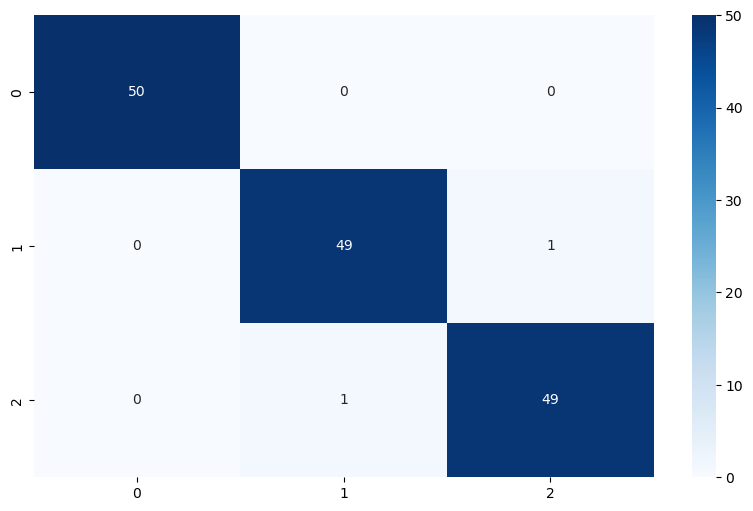

In [54]:
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap='Blues')

Ahora realizamos la misma optimización de parámetros pero sin utilizar componentes principales como features

In [40]:
rand_forest = RandomForestClassifier(random_state=42)
optim = RandomizedSearchCV(
    estimator=rand_forest,
    param_distributions={
        'n_estimators': np.arange(50, 150),
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': np.arange(5, 20),
        'min_samples_split': np.arange(2, 10),
        'min_samples_leaf': np.arange(1, 7)
    },
    random_state=42,
    scoring='precision_macro',
    n_jobs=2
)

search = optim.fit(X, y)
search.best_params_

{'n_estimators': 82,
 'min_samples_split': 9,
 'min_samples_leaf': 3,
 'max_depth': 17,
 'criterion': 'entropy'}

In [41]:
print('Precision:', search.best_score_.__format__('.2%'))

Precision: 97.07%


Para ver los grupos graficamente, volvemos ajustar el modelo con todos los datos y con los hiperparámetros óptimos, así podemos comparar visualmente con el gráfico de arriba:

In [55]:
forest = RandomForestClassifier(**search.best_params_, random_state=42)
y_pred = forest.fit(X, y).predict(X)

# Existing scatter plot
figure = px.scatter(
    x=pca.iloc[:, 0],
    y=pca.iloc[:, 1],
    color=y_pred.astype(str),
    color_discrete_map={'0': '#E65983', '1': '#2D3846'},
    size=[1] * pca.shape[0],
)

# Update layout
figure.update_layout(
    title='Clasificación con Random Forest',
    title_font=dict(size=16, family='Arial', color='black', weight='bold'),
    xaxis_title='PC1',
    yaxis_title='PC2',
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
    xaxis=dict(showgrid=True, gridcolor='LightGray', showline=True, linecolor='Black', zeroline=True, zerolinecolor='LightGray'),
)

figure.show()

<Axes: >

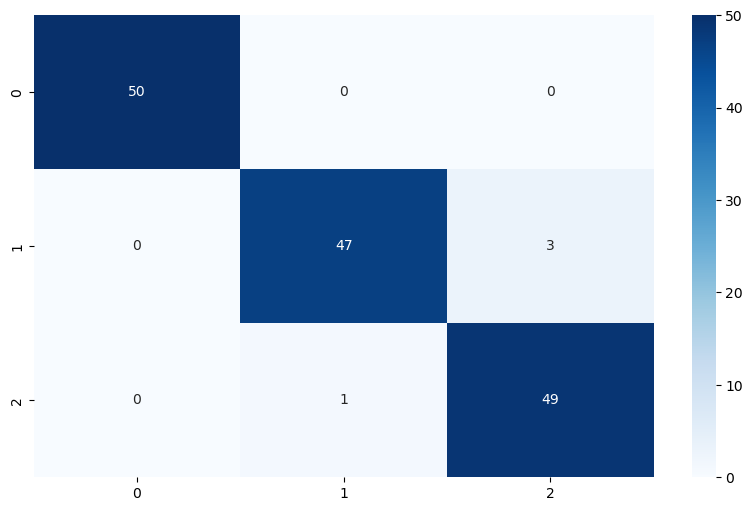

In [56]:
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap='Blues')